Download kml file from here: https://hls.gsfc.nasa.gov/products-description/tiling-system/

The actual download link is this: https://hls.gsfc.nasa.gov/wp-content/uploads/2016/03/S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml

In [41]:
import geopandas as gpd
import pandas as pd
from bs4 import BeautifulSoup
import fiona
import json
from tqdm import tqdm
from shapely import from_wkt 
from rasterio.crs import CRS
from shapely.geometry import Polygon, MultiPolygon, box
from shapely.affinity import translate

fiona.drvsupport.supported_drivers['LIBKML'] = 'rw'

In [2]:
df = gpd.read_file('S2A_OPER_GIP_TILPAR_MPC__20151209T095117_V20150622T000000_21000101T000000_B00.kml', driver='LIBKML')
df.head()

,Name,description,timestamp,begin,end,altitudeMode,tessellate,extrude,visibility,drawOrder,icon,snippet,geometry
0,01CCV,TILE PROPERTIES<br><table border=0 cellpadding...,NaT,NaT,NaT,None,-1,0,-1,None,None,,GEOMETRYCOLLECTION Z (POLYGON Z ((180.00000 -7...
1,01CDH,TILE PROPERTIES<br><table border=0 cellpadding...,NaT,NaT,NaT,None,-1,0,-1,None,None,,GEOMETRYCOLLECTION Z (POLYGON Z ((180.00000 -8...
2,01CDJ,TILE PROPERTIES<br><table border=0 cellpadding...,NaT,NaT,NaT,None,-1,0,-1,None,None,,GEOMETRYCOLLECTION Z (POLYGON Z ((180.00000 -8...
3,01CDK,TILE PROPERTIES<br><table border=0 cellpadding...,NaT,NaT,NaT,None,-1,0,-1,None,None,,GEOMETRYCOLLECTION Z (POLYGON Z ((180.00000 -8...
4,01CDL,TILE PROPERTIES<br><table border=0 cellpadding...,NaT,NaT,NaT,None,-1,0,-1,None,None,,GEOMETRYCOLLECTION Z (POLYGON Z ((180.00000 -8...


In [3]:
tile_properties_html = [record['description'] for record in df.to_dict('records')]
tile_properties_html[0]

'TILE PROPERTIES<br><table border=0 cellpadding=0 cellspacing=0  width=250 style="FONT-SIZE: 11px; FONT-FAMILY: Verdana, Arial, Helvetica, sans-serif;"><tr><td bgcolor="#E3E1CA" align="right"><font COLOR="#000000"><b>TILE_ID</b></font></td><td bgcolor="#E4E6CA"> <font COLOR="#008000">01CCV</font></td></tr><tr><td bgcolor="#E3E1CA" align="right"><font COLOR="#000000"><b>EPSG</b></font></td><td bgcolor="#E4E6CA"> <font COLOR="#008000">32701</font></td></tr><tr><td bgcolor="#E3E1CA" align="right"><font COLOR="#000000"><b>MGRS_REF</b></font></td><td bgcolor="#E4E6CA"> <font COLOR="#008000">-72.01265627 177.18928449 -72.077536527 -179.91249232 -72.972797991 179.93922476 -72.9043013 176.89507973</font></td></tr><tr><td bgcolor="#E3E1CA" align="right"><font COLOR="#000000"><b>UTM_WKT</b></font></td><td bgcolor="#E4E6CA"> <font COLOR="#008000">MULTIPOLYGON(((300000 2000020,300000 1890220,409800 1890220,409800 2000020,300000 2000020)))</font></td></tr><tr><td bgcolor="#E3E1CA" align="right"><fo

In [4]:
def get_tile_properties(html_data: str) -> dict:
    """Source: https://stackoverflow.com/a/18544794"""
    table_data = [[cell.text for cell in row("td")] 
                  for row in BeautifulSoup(html_data)("tr")]
    data = dict(table_data)
    return data

In [5]:
tile_properties = list(map(get_tile_properties, tqdm(tile_properties_html)))
tile_properties[:3]

100%|██████████████████████████████████| 56686/56686 [00:19<00:00, 2903.19it/s]


[{'TILE_ID': ' 01CCV',
  'EPSG': ' 32701',
  'MGRS_REF': ' -72.01265627 177.18928449 -72.077536527 -179.91249232 -72.972797991 179.93922476 -72.9043013 176.89507973',
  'UTM_WKT': ' MULTIPOLYGON(((300000 2000020,300000 1890220,409800 1890220,409800 2000020,300000 2000020)))',
  'LL_WKT': ' MULTIPOLYGON(((177.189340361676 -72.0124778858137,176.864623786205 -72.9914734627827,-179.775147078577 -73.064632943735,-179.627444421211 -72.081397340079,177.189340361676 -72.0124778858137)))'},
 {'TILE_ID': ' 01CDH',
  'EPSG': ' 32701',
  'MGRS_REF': ' -82.796942202 175.83834491 -82.852560274 -177 -83.748345357 -177 -83.684758644 174.83020094',
  'UTM_WKT': ' MULTIPOLYGON(((399960 800020,399960 690220,509760 690220,509760 800020,399960 800020)))',
  'LL_WKT': ' MULTIPOLYGON(((175.835686552199 -82.7967201119087,174.712881529024 -83.7714121109537,-176.185902759418 -83.8353338950151,-176.297440454183 -82.8518492389837,175.835686552199 -82.7967201119087)))'},
 {'TILE_ID': ' 01CDJ',
  'EPSG': ' 32701',


In [24]:
df = pd.DataFrame(tile_properties)
df.columns = [col.lower() for col in df.columns]
df.head()

,tile_id,epsg,mgrs_ref,utm_wkt,ll_wkt
0,01CCV,32701,-72.01265627 177.18928449 -72.077536527 -179....,"MULTIPOLYGON(((300000 2000020,300000 1890220,...",MULTIPOLYGON(((177.189340361676 -72.012477885...
1,01CDH,32701,-82.796942202 175.83834491 -82.852560274 -177...,"MULTIPOLYGON(((399960 800020,399960 690220,50...",MULTIPOLYGON(((175.835686552199 -82.796720111...
2,01CDJ,32701,-81.907342379 176.62455327 -81.956740238 -177...,"MULTIPOLYGON(((399960 900040,399960 790240,50...",MULTIPOLYGON(((176.62230379644 -81.9069468576...
3,01CDK,32701,-81.01647427 177.25448324 -81.060880975 -177 ...,"MULTIPOLYGON(((399960 1000000,399960 890200,5...",MULTIPOLYGON(((177.252200236163 -81.016438828...
4,01CDL,32701,-80.124666236 177.77028412 -80.164978249 -177...,"MULTIPOLYGON(((399960 1100020,399960 990220,5...",MULTIPOLYGON(((177.768297510956 -80.124455609...


In [25]:
df.iloc[0].ll_wkt

' MULTIPOLYGON(((177.189340361676 -72.0124778858137,176.864623786205 -72.9914734627827,-179.775147078577 -73.064632943735,-179.627444421211 -72.081397340079,177.189340361676 -72.0124778858137)))'

In [46]:
df_mgrs = gpd.GeoDataFrame(df, geometry=[from_wkt(wkt) for wkt in df.ll_wkt.tolist()], crs=CRS.from_epsg(4326))
# Ensures multipologyns generated from_wkt are cast to polygons
df_mgrs_t = df_mgrs.explode(ignore_index=True)
assert df_mgrs_t.shape == df_mgrs.shape
df_mgrs = df_mgrs_t
df_mgrs.drop(columns=['mgrs_ref', 'll_wkt'], inplace=True)
df_mgrs.head()

,tile_id,epsg,utm_wkt,geometry
0,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,...","POLYGON ((177.18934 -72.01248, 176.86462 -72.9..."
1,01CDH,32701,"MULTIPOLYGON(((399960 800020,399960 690220,50...","POLYGON ((175.83569 -82.79672, 174.71288 -83.7..."
2,01CDJ,32701,"MULTIPOLYGON(((399960 900040,399960 790240,50...","POLYGON ((176.62230 -81.90695, 175.74819 -82.8..."
3,01CDK,32701,"MULTIPOLYGON(((399960 1000000,399960 890200,5...","POLYGON ((177.25220 -81.01644, 176.55270 -81.9..."
4,01CDL,32701,"MULTIPOLYGON(((399960 1100020,399960 990220,5...","POLYGON ((177.76830 -80.12446, 177.19616 -81.1..."


In [47]:
df_mgrs

,tile_id,epsg,utm_wkt,geometry
0,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,...","POLYGON ((177.18934 -72.01248, 176.86462 -72.9..."
1,01CDH,32701,"MULTIPOLYGON(((399960 800020,399960 690220,50...","POLYGON ((175.83569 -82.79672, 174.71288 -83.7..."
2,01CDJ,32701,"MULTIPOLYGON(((399960 900040,399960 790240,50...","POLYGON ((176.62230 -81.90695, 175.74819 -82.8..."
3,01CDK,32701,"MULTIPOLYGON(((399960 1000000,399960 890200,5...","POLYGON ((177.25220 -81.01644, 176.55270 -81.9..."
4,01CDL,32701,"MULTIPOLYGON(((399960 1100020,399960 990220,5...","POLYGON ((177.76830 -80.12446, 177.19616 -81.1..."
...,...,...,...,...
56681,60XWM,32660,"MULTIPOLYGON(((499980 8700000,499980 8590200,...","POLYGON ((176.99911 78.37303, 176.99918 77.389..."
56682,60XWN,32660,"MULTIPOLYGON(((499980 8800020,499980 8690220,...","POLYGON ((176.99904 79.26921, 176.99912 78.285..."
56683,60XWP,32660,"MULTIPOLYGON(((499980 8900040,499980 8790240,...","POLYGON ((176.99895 80.16534, 176.99905 79.181..."
56684,60XWQ,32660,"MULTIPOLYGON(((499980 9000000,499980 8890200,...","POLYGON ((176.99885 81.06088, 176.99896 80.077..."


In [48]:
df_mgrs['utm_wkt'] = df_mgrs['utm_wkt'].str.strip()
df_mgrs['tile_id'] = df_mgrs['tile_id'].str.strip()

The lat/lon are malformed (going basically across the globe)

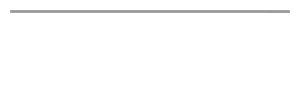

In [49]:
anti_meridian_tile_id = '01TBG'
df_mgrs[df_mgrs.tile_id == anti_meridian_tile_id].geometry.values[0]

The UTMs are fine.

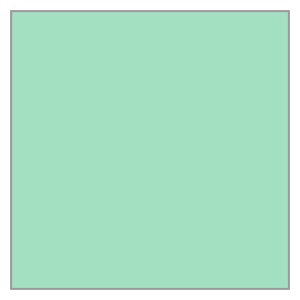

In [50]:
from_wkt(df_mgrs[df_mgrs.tile_id == anti_meridian_tile_id]['utm_wkt'].tolist()[0])

We are going to make multipolygons following the burst database.

In [51]:
def fix_antimeridian_polygon(geometry):
    """Fixes a polygon that should cross the antimeridian by creating two corrected polygons."""
    # Define the bounding box for intersection
    world_box = box(-180, -90, 180, 90)
    minx, miny, maxx, maxy = geometry.bounds
    
    # Only process polygons that are too wide (threshold set to 170)
    if maxx - minx > 170:
        # Separate points near -180 and +180
        coords = list(geometry.exterior.coords)
        left_coords = [(x - 360 if x > 170 else x, y) for x, y in coords]
        right_coords = [(x + 360 if x < -170 else x, y) for x, y in coords]
        
        # Create two polygons
        left_polygon = Polygon(left_coords)
        right_polygon = Polygon(right_coords)
        
        # Combine into a multipolygon and intersect with world bounds
        combined = MultiPolygon([left_polygon, right_polygon])
        return combined.intersection(world_box)

    # If no fix is needed, return original geometry
    return geometry

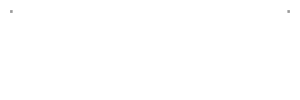

In [52]:
df_mgrs_final = df_mgrs.copy()
df_mgrs_final.geometry = df_mgrs_final.geometry.map(fix_antimeridian_polygon)
df_mgrs_final[df_mgrs_final.tile_id == anti_meridian_tile_id].geometry.values[0]

In [56]:
df_mgrs_final.head()

,tile_id,epsg,utm_wkt,geometry
0,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.08140, -179.775..."
1,01CDH,32701,"MULTIPOLYGON(((399960 800020,399960 690220,509...","MULTIPOLYGON (((-176.29744 -82.85185, -176.185..."
2,01CDJ,32701,"MULTIPOLYGON(((399960 900040,399960 790240,509...","MULTIPOLYGON (((-176.37525 -81.95591, -176.288..."
3,01CDK,32701,"MULTIPOLYGON(((399960 1000000,399960 890200,50...","MULTIPOLYGON (((-176.43739 -81.06046, -176.368..."
4,01CDL,32701,"MULTIPOLYGON(((399960 1100020,399960 990220,50...","MULTIPOLYGON (((-176.48820 -80.16441, -176.431..."


In [57]:
df_mgrs_final.to_parquet('mgrs.parquet')

In [58]:
df_mgrs_final.to_file('mgrs.geojson', driver='GeoJSON')